# 📚 SlideScholar — Notebook 1: Ingestion Pipeline
### STATGR5293 · GenAI Using LLMs · Spring 2026 · Columbia University

**Input:** `My Drive/SlideScholar/Slides_Input/` — all PDF and PPTX files, auto-discovered  
**Output:** `My Drive/SlideScholar/index/chunks.json` — consumed by Notebook 2  

---

## Design principles

- **Zero hardcoding** — drop any PDF or PPTX into `Slides_Input/` and it gets ingested automatically
- **No manual config** — lecture names and numbers are extracted from filenames automatically
- **Incremental** — re-run anytime; already-processed files are skipped
- **Fault-tolerant** — saved to Drive after every file; a crash only loses the current file

```
Slides_Input/ (any files, any time)
      │
      ▼
  auto_discover()     scan folder → extract name + lecture_num from filename
      │
      ▼
  parse_file()        text per slide + PNG per slide  (PDF or PPTX)
      │
      ▼
  describe_slide()    LLaVA-7B vision → diagram / equation / chart description
      │
      ▼
  make_chunk()        merge text + vision + metadata → chunk dict
      │
      ▼
  batch_ingest()      save to Drive after every file
      │
      ▼
  chunks.json         → Notebook 2 reads this
```

---
> Requires **A100 GPU** — Runtime → Change runtime type → A100 before starting.


## Section 0 · Runtime Verification

Confirms GPU is available before doing anything. If this shows no GPU:
**Runtime → Change runtime type → GPU → A100 → Save**, then rerun from top.

In [1]:
import sys

try:
    import torch
    assert torch.cuda.is_available(), 'No GPU detected'
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅  GPU : {gpu_name}')
    print(f'✅  VRAM: {vram_gb:.1f} GB')
    if 'A100' in gpu_name:
        print('✅  A100 confirmed — optimal for this notebook')
    elif 'T4' in gpu_name:
        print('⚠️  T4 detected — will work but monitor VRAM closely')
    else:
        print(f'ℹ️  {gpu_name} — proceed but monitor VRAM')
except ImportError:
    print('⚠️  PyTorch not yet installed — continue to Section 1')
except AssertionError as e:
    print(f'❌  {e} — go to Runtime → Change runtime type → A100')

py = sys.version_info
assert py >= (3, 9), f'Python 3.9+ required, got {py.major}.{py.minor}'
print(f'✅  Python {py.major}.{py.minor}.{py.micro}')

✅  GPU : NVIDIA A100-SXM4-40GB
✅  VRAM: 42.4 GB
✅  A100 confirmed — optimal for this notebook
✅  Python 3.12.13


In [4]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [2]:
!pip install -q tokenizers==0.19.1

In [3]:
import shutil
print(shutil.which("pdfinfo"))   # should print /usr/bin/pdfinfo
!pdfinfo -v                       # should print version info

/usr/bin/pdfinfo
pdfinfo version 22.02.0
Copyright 2005-2022 The Poppler Developers - http://poppler.freedesktop.org
Copyright 1996-2011 Glyph & Cog, LLC



## Section 1 · Install Dependencies

All versions are pinned. `Pillow 9.5.0` + `python-pptx 0.6.23` are used together to
avoid the `is_directory` import conflict that occurs with newer versions on Colab.

**After this cell finishes: Runtime → Restart session, then skip to Section 2.**

In [4]:
!pip uninstall -y Pillow python-pptx 2>/dev/null

!pip install -q \
    pdfplumber==0.11.0 \
    pdf2image==1.17.0 \
    'Pillow==9.5.0' \
    'python-pptx==0.6.23' \
    transformers==4.40.0 \
    bitsandbytes==0.43.1 \
    accelerate==0.29.3

!apt-get install -qq poppler-utils libreoffice 2>/dev/null

print('\nAll packages installed')
print('Now go to: Runtime → Restart session')
print('   After restart, skip Section 1 and run from Section 2 downward')

Found existing installation: Pillow 9.5.0
Uninstalling Pillow-9.5.0:
  Successfully uninstalled Pillow-9.5.0
Found existing installation: python-pptx 0.6.23
Uninstalling python-pptx-0.6.23:
  Successfully uninstalled python-pptx-0.6.23
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.

All packages installed
Now go to: Runtime → Restart session
   After restart, skip Section 1 and run from Section 2 downward



## Section 2 · Imports & Version Verification

Start here after restarting the runtime. If any import fails, re-run Section 1.

In [1]:
import subprocess
subprocess.run(["apt-get", "install", "-y", "poppler-utils"], capture_output=True)
!apt-get install -y libreoffice  # must use ! not subprocess — libreoffice install is interactive
print("poppler-utils and libreoffice ready")
print("System packages ready (poppler + libreoffice)")

# ── Standard imports
import os, re, json, time, hashlib, subprocess, textwrap
from pathlib import Path
from typing  import List, Dict, Tuple, Optional

import pdfplumber
from pdf2image import convert_from_path
print(f'pdfplumber {pdfplumber.__version__}')

from pptx import Presentation
import pptx
print(f'python-pptx {pptx.__version__}')

from PIL import Image
import PIL
print(f'Pillow {PIL.__version__}')

import torch
import transformers
from transformers import (
    LlavaForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
print(f'PyTorch      {torch.__version__}')
print(f'Transformers {transformers.__version__}')
print(f'CUDA         {torch.cuda.is_available()}')

print('\nAll imports successful')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  apparmor at-spi2-core default-jre default-jre-headless dictionaries-common
  firebird3.0-common firebird3.0-common-doc firebird3.0-server-core
  firebird3.0-utils fonts-crosextra-caladea fonts-crosextra-carlito
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra fonts-liberation2
  fonts-linuxlibertine fonts-noto-core fonts-noto-extra fonts-noto-mono
  fonts-noto-ui-core fonts-opensymbol fonts-sil-gentium
  fonts-sil-gentium-basic gsettings-desktop-schemas gstreamer1.0-gl
  gstreamer1.0-gtk3 gstreamer1.0-plugins-base hunspell-en-us libabsl20210324
  libabw-0.1-1 libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libboost-filesystem1.74.0
  libboost-iostreams1.74.0 libboost-locale1.74.0 libboost-thread1.74.0
  libbsh-java libcdparanoia0 libcdr-0.1-1 libclucene-contribs1v5
  libclucen


## Section 3 · Google Drive Mount & Path Configuration

Mounts Drive and sets up all paths. No manual path editing needed.

```
My Drive/
└── SlideScholar/
    ├── Slides_Input/          ← drop any PDF or PPTX here anytime
    ├── index/
    │   └── chunks.json        ← MAIN OUTPUT — Notebook 2 reads this
    └── logs/
        └── ingestion_log.json ← tracks processed files for incremental runs
```

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT   = Path('/content/drive/MyDrive/SlideScholar')
SLIDES_INPUT = DRIVE_ROOT / 'Slides_Input'
INDEX_DIR    = DRIVE_ROOT / 'index'
LOG_DIR      = DRIVE_ROOT / 'logs'
CHUNKS_PATH  = INDEX_DIR  / 'chunks.json'
INGEST_LOG   = LOG_DIR    / 'ingestion_log.json'

for d in [INDEX_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not SLIDES_INPUT.exists():
    print(f'❌  Not found: {SLIDES_INPUT}')
    print('   Check that your Drive folder is: My Drive/SlideScholar/Slides_Input/')
else:
    print(f'Drive mounted')
    print(f'Slides_Input : {SLIDES_INPUT}')
    print(f'Output       : {CHUNKS_PATH}')
    print(f'Log          : {INGEST_LOG}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
Slides_Input : /content/drive/MyDrive/SlideScholar/Slides_Input
Output       : /content/drive/MyDrive/SlideScholar/index/chunks.json
Log          : /content/drive/MyDrive/SlideScholar/logs/ingestion_log.json



## Section 4 · Auto-Discovery

Scans `Slides_Input/` and automatically extracts a clean name and lecture number
from each filename. No manual configuration needed.

### How name extraction works

The filename is cleaned by:
1. Removing the extension
2. Stripping course codes (`GR5293`, `STAT_GR5293`, `sec002`)
3. Stripping location/semester noise (`columbia`, `spring-2026`, `Spring2026`, `latest`)
4. Converting hyphens and underscores to spaces
5. Title-casing the result

### How lecture number extraction works

Regex searches the filename for patterns like `Lecture-3`, `Lecture-10-part2`, `lecture_7`.
If found, `lecture_num` is set (e.g. `10`, `10.2` for part 2). If not found — guest lectures,
notes, supplementary files — `lecture_num` is `None`. This is fine: the chunk is still
fully indexed and searchable. Lecture number is only metadata for display.

### Adding files later

Drop new files into `Slides_Input/` anytime and re-run this cell and Section 11.
Already-ingested files are automatically skipped.

In [3]:
SUPPORTED_EXTENSIONS = {'.pdf', '.pptx'}

# ── Noise tokens to strip from filenames when generating display names ────────
# Add more here if different naming conventions used
_NOISE = [
    r'STAT[_-]GR\d+', r'GR\d+', r'sec\d+', r'section\d+',
    r'columbia', r'spring[_-]?\d{4}', r'fall[_-]?\d{4}',
    r'spring\d{4}', r'fall\d{4}',
    r'latest', r'updated', r'final', r'v\d+',
]
_NOISE_RE = re.compile(
    '|'.join(_NOISE),
    flags=re.IGNORECASE
)


def extract_lecture_num(filename: str) -> Optional[float]:
    """
    Extract lecture number from filename. Returns float so part2 → N.2.
    Returns None if no lecture number found.

    Examples
    --------
    'Lecture-3-...'          → 3.0
    'Lecture-10-part2-...'  → 10.2
    'Lecture-10-part1-...'  → 10.1
    'Dhava_Patel_Slide...'  → None
    """
    # Match Lecture-N or lecture_N, optionally followed by -partM
    m = re.search(
        r'lecture[_-](\d+)(?:[_-]part(\d+))?',
        filename,
        flags=re.IGNORECASE
    )
    if not m:
        return None
    num  = int(m.group(1))
    part = int(m.group(2)) if m.group(2) else 0
    return float(f'{num}.{part}') if part else float(num)


def extract_display_name(filename: str) -> str:
    """
    Generate a clean human-readable display name from a filename.

    Examples
    --------
    'GR5293_Lecture-1-columbia-Spring2026-sec002.pdf'
        → 'Lecture 1'
    'STAT_GR5293_sec002_Lecture-10-part2-columbia-spring-2026.pdf'
        → 'Lecture 10 Part 2'
    'Dhava_Patel_Slide_Columbia.pptx'
        → 'Dhava Patel Slide'
    """
    stem = Path(filename).stem
    # Remove noise tokens
    cleaned = _NOISE_RE.sub(' ', stem)
    # Replace separators with spaces
    cleaned = re.sub(r'[_\-]+', ' ', cleaned)
    # Collapse multiple spaces
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    # Title-case
    return cleaned.title() if cleaned else stem


def auto_discover(slides_dir: Path) -> List[Dict]:
    """
    Scan slides_dir for all supported files and return a list of file configs.
    Each config dict has: path, name, lecture_num.
    Sorted by lecture_num (None files go last, alphabetically among themselves).
    """
    files = sorted([
        f for f in slides_dir.iterdir()
        if f.suffix.lower() in SUPPORTED_EXTENSIONS
    ])

    configs = []
    for f in files:
        configs.append({
            'path':        str(f),
            'name':        extract_display_name(f.name),
            'lecture_num': extract_lecture_num(f.name),
            'filename':    f.name,
        })

    # Sort: numbered lectures first (by number), then unnumbered alphabetically
    configs.sort(key=lambda c: (
        0 if c['lecture_num'] is not None else 1,
        c['lecture_num'] if c['lecture_num'] is not None else 0,
        c['filename'],
    ))
    return configs


print('auto_discover() defined')
print('extract_lecture_num() defined')
print('extract_display_name() defined')

auto_discover() defined
extract_lecture_num() defined
extract_display_name() defined


### Run discovery — preview what will be ingested

Check the names and numbers look right. If any name looks wrong, you can override
it in the optional override cell below — but in most cases the auto-extraction works.

In [4]:
LECTURE_FILES = auto_discover(SLIDES_INPUT)

print(f'Found {len(LECTURE_FILES)} file(s) in Slides_Input:\n')
print(f'  {"Lec":>5}  {"Type":4}  {"Size MB":>8}  {"Display Name":<40}  Filename')
print(f'  {"-"*5}  {"-"*4}  {"-"*8}  {"-"*40}  {"-"*30}')

for cfg in LECTURE_FILES:
    p       = Path(cfg['path'])
    size_mb = p.stat().st_size / 1e6
    lec     = str(cfg['lecture_num']) if cfg['lecture_num'] is not None else 'N/A'
    ftype   = p.suffix.upper()[1:]
    print(f'  {lec:>5}  {ftype:4}  {size_mb:8.1f}  {cfg["name"]:<40}  {p.name}')

numbered   = sum(1 for c in LECTURE_FILES if c['lecture_num'] is not None)
unnumbered = len(LECTURE_FILES) - numbered
print(f'\n  Total: {len(LECTURE_FILES)}  |  Numbered: {numbered}  |  Unnumbered (guest/notes): {unnumbered}')

Found 14 file(s) in Slides_Input:

    Lec  Type   Size MB  Display Name                              Filename
  -----  ----  --------  ----------------------------------------  ------------------------------
    1.0  PDF       10.7  Lecture 1                                 GR5293_Lecture-1-columbia-Spring2026-sec002.pdf
    2.0  PDF        6.0  Lecture 2                                 GR5293_sec002_Lecture-2-columbia-spring-2026.pdf
    3.0  PDF       10.4  Lecture 3                                 STAT_GR5293_sec002_Lecture-3-latest-columbia-spring-2026.pdf
    4.0  PDF       15.3  Lecture 4                                 STAT_GR5293_sec002_Lecture-4-latest-columbia-spring-2026.pdf
    5.0  PDF       34.7  Lecture 5                                 STAT_GR5293_sec002_Lecture-5-latest-columbia-spring-2026.pdf
    6.0  PDF       17.1  Lecture 6                                 STAT_GR5293_sec002_Lecture-6-columbia-spring-2026.pdf
    7.0  PDF        8.3  Lecture 7                     

### Optional: Override any auto-generated name

If the auto-extracted name for any file looks wrong, add an override here.
Leave the dict empty `{}` if everything looks correct — which it usually will.

Key = exact filename. Value = the name you want displayed in citations.

In [5]:
# ── Add overrides here if needed — leave empty if auto-names look correct ────
NAME_OVERRIDES = {
    # 'Dhava_Patel_Slide_Columbia.pptx': 'Guest Lecture: Dhava Patel (Industry Applications)',
    # 'GR5293_Lecture-1-columbia-Spring2026-sec002.pdf': 'Lecture 1: Intro to GenAI & LLMs',
}

# Apply overrides
for cfg in LECTURE_FILES:
    if cfg['filename'] in NAME_OVERRIDES:
        old_name = cfg['name']
        cfg['name'] = NAME_OVERRIDES[cfg['filename']]
        print(f'Override: "{old_name}" → "{cfg["name"]}"')

if not NAME_OVERRIDES:
    print('No overrides — using auto-generated names')
print('\nLECTURE_FILES ready for ingestion')

No overrides — using auto-generated names

LECTURE_FILES ready for ingestion



## Section 5 · PDF Parser

`pdfplumber` extracts text with layout awareness. `pdf2image` (wrapping poppler) renders
each page as a PIL image at 150 DPI — enough for LLaVA to read diagrams and equations
clearly without excessive memory use (~0.5 MB per slide).

| Edge case | Handling |
|---|---|
| Empty page | `''` for text, image still captured |
| Scanned PDF (no text layer) | Flagged `is_scanned=True` — LLaVA is the sole text source |
| Page count mismatch | Assertion error with clear message |
| Text extraction failure | Logs warning, uses `''`, continues |

In [6]:
def parse_pdf(pdf_path: str, dpi: int = 150) -> List[Tuple[str, Image.Image]]:
    """
    Parse a PDF into (text, image) tuples, one per page.
    Returns List[(text: str, image: PIL.Image)].
    """
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f'PDF not found: {pdf_path}')

    try:
        images = convert_from_path(str(pdf_path), dpi=dpi)
    except Exception as e:
        raise RuntimeError(
            f'pdf2image failed on {pdf_path.name}: {e}\n'
            'Run: !apt-get install -qq poppler-utils'
        ) from e

    texts = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        for i, page in enumerate(pdf.pages):
            try:
                raw = page.extract_text()
                texts.append(raw.strip() if raw else '')
            except Exception as e:
                print(f'  Page {i+1}: text extraction failed ({e})')
                texts.append('')

    assert len(texts) == len(images), (
        f'Page count mismatch in {pdf_path.name}: '
        f'{len(texts)} text vs {len(images)} images'
    )
    return list(zip(texts, images))


def is_scanned(slides: List[Tuple[str, Image.Image]],
               threshold: float = 0.7) -> bool:
    """True if >70% of slides have fewer than 20 chars of extracted text."""
    empty = sum(1 for text, _ in slides if len(text.strip()) < 20)
    return (empty / len(slides)) > threshold if slides else False


print('parse_pdf() defined')
print('is_scanned() defined')

parse_pdf() defined
is_scanned() defined


### Quick test — first PDF in your folder

Testing on: GR5293_Lecture-1-columbia-Spring2026-sec002.pdf
93 slides in 13.1s  |  scanned: False

── Slide 1 text (first 300 chars) ──
[EMPTY — likely scanned]

── Slide 1 image (2001×1125) ──


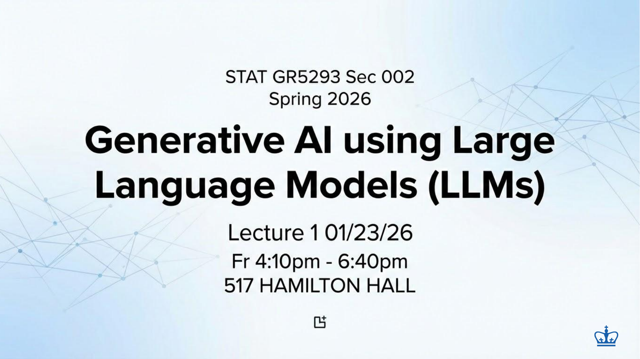

In [7]:
pdf_files = [c for c in LECTURE_FILES if Path(c['path']).suffix.lower() == '.pdf']

if pdf_files:
    test = pdf_files[0]
    print(f'Testing on: {Path(test["path"]).name}')
    t0     = time.time()
    slides = parse_pdf(test['path'])
    print(f'{len(slides)} slides in {time.time()-t0:.1f}s  |  scanned: {is_scanned(slides)}')
    text0, img0 = slides[0]
    print(f'\n── Slide 1 text (first 300 chars) ──')
    print(textwrap.fill(text0[:300] or '[EMPTY — likely scanned]', width=80))
    print(f'\n── Slide 1 image ({img0.size[0]}×{img0.size[1]}) ──')
    display(img0.resize((640, int(640 * img0.size[1] / img0.size[0]))))
else:
    print('No PDFs found in Slides_Input')


## Section 6 · PPTX Parser

python-pptx extracts text (shapes sorted top-to-bottom for reading order).
LibreOffice converts PPTX → PDF so pdf2image can render each slide as an image.
The output format is identical to `parse_pdf()` — the rest of the pipeline
doesn't know or care which format the source file was.

In [8]:
def _pptx_texts(prs: Presentation) -> List[str]:
    """Extract text per slide, shapes sorted top-to-bottom."""
    result = []
    for slide in prs.slides:
        shapes = sorted(
            [s for s in slide.shapes if s.has_text_frame],
            key=lambda s: s.top if s.top is not None else 0
        )
        lines = []
        for shape in shapes:
            for para in shape.text_frame.paragraphs:
                line = para.text.strip()
                if line:
                    lines.append(line)
        result.append('\n'.join(lines))
    return result


def _pptx_images(pptx_path: Path, dpi: int = 150) -> List[Image.Image]:
    """
    Render PPTX slides to images without LibreOffice.
    Creates a white canvas per slide and pastes any embedded picture shapes.
    Text is captured separately by _pptx_texts() and LLaVA reads the image.
    No system dependencies required.
    """
    from io import BytesIO

    prs    = Presentation(str(pptx_path))
    width  = int(prs.slide_width  * dpi / 914400)   # EMU → pixels
    height = int(prs.slide_height * dpi / 914400)
    images = []

    for slide in prs.slides:
        canvas = Image.new("RGB", (width, height), "white")

        for shape in slide.shapes:
            if shape.shape_type == 13:   # embedded picture
                try:
                    img  = Image.open(BytesIO(shape.image.blob)).convert("RGB")
                    left = int(shape.left   * width  / prs.slide_width)
                    top  = int(shape.top    * height / prs.slide_height)
                    w    = int(shape.width  * width  / prs.slide_width)
                    h    = int(shape.height * height / prs.slide_height)
                    canvas.paste(img.resize((w, h), Image.LANCZOS), (left, top))
                except Exception:
                    pass

        images.append(canvas)

    return images


def parse_pptx(pptx_path: str, dpi: int = 150) -> List[Tuple[str, Image.Image]]:
    """
    Parse a PPTX into (text, image) tuples, one per slide.
    Returns List[(text: str, image: PIL.Image)].
    """
    p = Path(pptx_path)
    if not p.exists():
        raise FileNotFoundError(f'PPTX not found: {p}')
    prs    = Presentation(str(p))
    texts  = _pptx_texts(prs)
    images = _pptx_images(p, dpi=dpi)
    assert len(texts) == len(images), (
        f'Slide count mismatch in {p.name}: {len(texts)} text vs {len(images)} images'
    )
    return list(zip(texts, images))


print('parse_pptx() defined')

parse_pptx() defined


### Quick test — first PPTX in your folder

PPTX files found: 2
  STAT_GR5293_sec002_Lecture-11-columbia-spring-2026.pptx
  Dhava_Patel_Slide_Columbia.pptx

Testing on: STAT_GR5293_sec002_Lecture-11-columbia-spring-2026.pptx
  LibreOffice conversion running (10–30s)...
39 slides in 4.8s

── Slide 1 text ──
Generative AI using Large Language Models (LLMs) Lecture 11 | 04/10/25
Instructor: Chen Wang Fri 4:10 pm - 6:40 pm | 517 Hamilton Hall

── Slide 1 image (2000×1125) ──


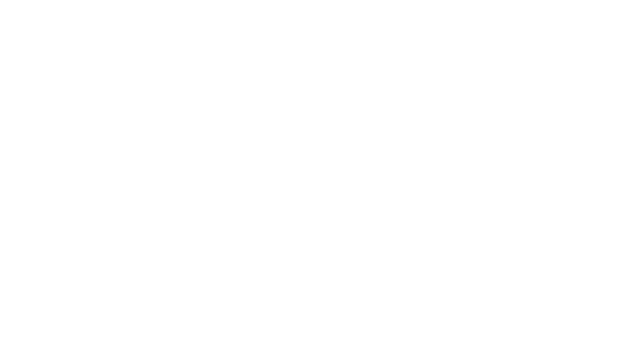

In [9]:
pptx_files = [c for c in LECTURE_FILES if Path(c['path']).suffix.lower() == '.pptx']

print(f"PPTX files found: {len(pptx_files)}")
for f in pptx_files:
    print(f"  {f['filename']}")

if pptx_files:
    test = pptx_files[0]
    print(f'\nTesting on: {Path(test["path"]).name}')
    print('  LibreOffice conversion running (10–30s)...')
    t0     = time.time()
    slides = parse_pptx(test['path'])
    print(f'{len(slides)} slides in {time.time()-t0:.1f}s')
    text0, img0 = slides[0]
    print(f'\n── Slide 1 text ──')
    print(textwrap.fill(text0[:300] or '[EMPTY]', width=80))
    print(f'\n── Slide 1 image ({img0.size[0]}×{img0.size[1]}) ──')
    display(img0.resize((640, int(640 * img0.size[1] / img0.size[0]))))
else:
    print('No PPTX files in LECTURE_FILES')

For the two PPTX files the canvas will show embedded images correctly but won't render text shapes as visible text in the image. That's fine because _pptx_texts() already extracts all the text separately, and that text goes directly into chunk['text'] for embedding. LLaVA gets the image for diagrams and pictures. The only loss is that LLaVA won't see text-as-rendered on PPTX slides — but since _pptx_texts() already has that text, nothing is actually missing from the chunk.


## Section 7 · Unified File Parser

Single entry point that routes to `parse_pdf()` or `parse_pptx()` automatically.
This is the only parsing function `ingest_file()` calls.

In [10]:
def parse_file(file_path: str, dpi: int = 150) -> List[Tuple[str, Image.Image]]:
    """
    Parse any PDF or PPTX file into (text, image) tuples.
    Routes automatically based on file extension.
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    ext = path.suffix.lower()
    if ext not in SUPPORTED_EXTENSIONS:
        raise ValueError(f'Unsupported: {ext}. Supported: {SUPPORTED_EXTENSIONS}')
    return parse_pdf(str(path), dpi=dpi) if ext == '.pdf' else parse_pptx(str(path), dpi=dpi)


print('parse_file() defined — routes PDF and PPTX automatically')

parse_file() defined — routes PDF and PPTX automatically



## Section 8 · LLaVA-7B Vision Model

LLaVA reads each slide image and produces a rich text description covering everything
pdfplumber cannot extract: diagrams, flowcharts, equations with their meaning,
chart axes and trends, and visual structure.

**4-bit NF4 quantization** reduces VRAM from ~14 GB (fp16) to ~9 GB with minimal
quality loss — comfortably fits on A100, tight but workable on T4.

> First run downloads ~15 GB. Takes 3–8 minutes. Subsequent runs in the same session are instant.

In [14]:
LLAVA_MODEL_ID = 'llava-hf/llava-1.5-7b-hf'

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = 'nf4',
    bnb_4bit_compute_dtype    = torch.float16,
    bnb_4bit_use_double_quant = True,
)

print('Loading processor...')
from transformers import AutoImageProcessor, AutoTokenizer, LlavaProcessor
image_processor = AutoImageProcessor.from_pretrained(LLAVA_MODEL_ID)
tokenizer       = AutoTokenizer.from_pretrained(LLAVA_MODEL_ID, use_fast=False)
llava_processor = LlavaProcessor(image_processor=image_processor, tokenizer=tokenizer)
print('Processor loaded')

print('\nLoading LLaVA-7B in fp16 (no quantization — A100 has enough VRAM)...')
t0 = time.time()
llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_MODEL_ID,
    device_map  = 'auto',
    torch_dtype = torch.float16,
    low_cpu_mem_usage = True,
)
llava_model.eval()
print(f'LLaVA-7B loaded in {time.time()-t0:.0f}s')
print(f'   VRAM used : {torch.cuda.memory_allocated()/1e9:.1f} GB')
print(f'   VRAM free : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB')

Loading processor...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Processor loaded

Loading LLaVA-7B in fp16 (no quantization — A100 has enough VRAM)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA-7B loaded in 7s
   VRAM used : 14.2 GB
   VRAM free : 28.2 GB


In [15]:
# Vision prompt
# Asks for: all text, diagrams, equations, charts, overall concept.
# 'ASSISTANT:' suffix is required by LLaVA-1.5's chat template.
VISION_PROMPT = (
    'USER: <image>\n'
    'You are analyzing a university lecture slide. Describe it comprehensively:\n'
    '1. ALL visible text exactly as written (titles, bullets, labels).\n'
    '2. Any diagrams or flowcharts — describe spatial layout and what they show.\n'
    '3. Any equations or formulas — write them out and explain what they mean.\n'
    '4. Any charts or graphs — axes, labels, trends, key values.\n'
    '5. Overall: what concept is this slide teaching?\n'
    'A student who cannot see this slide should understand it fully from your description.\n'
    'ASSISTANT:'
)


def describe_slide(
    image:          Image.Image,
    max_new_tokens: int   = 450,
    temperature:    float = 0.1,
) -> str:
    """
    Run LLaVA-7B on a single slide image.
    Returns rich text description. On OOM or error: returns placeholder string.
    Never crashes — errors are logged and ingestion continues.
    """
    if image.mode != 'RGB':
        image = image.convert('RGB')
    try:
        inputs = llava_processor(
            text=VISION_PROMPT, images=image, return_tensors='pt'
        ).to('cuda')
        with torch.no_grad():
            out = llava_model.generate(
                **inputs,
                max_new_tokens = max_new_tokens,
                temperature    = temperature,
                do_sample      = temperature > 0,
                pad_token_id   = llava_processor.tokenizer.eos_token_id,
            )
        decoded = llava_processor.decode(out[0], skip_special_tokens=True)
        return decoded.split('ASSISTANT:')[-1].strip()
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print('  OOM — cache cleared, skipping vision for this slide')
        return '[VISION FAILED: OOM]'
    except Exception as e:
        print(f'  Vision error: {e}')
        return f'[VISION FAILED: {str(e)[:80]}]'


print('describe_slide() defined')

describe_slide() defined


### Test vision on slide 1 of your first test file

In [16]:
# Uses whichever test file was parsed successfully above (PDF or PPTX)
_test = None
if 'slides' in dir() and slides:
    _test = slides
elif 'pdf_files' in dir() and pdf_files:
    _test = parse_pdf(pdf_files[0]['path'])

if _test:
    _, _img = _test[0]
    print('Running LLaVA on slide 1...')
    t0  = time.time()
    out = describe_slide(_img)
    print(f'{time.time()-t0:.1f}s  |  {len(out)} chars')
    print('\n── LLaVA output ──')
    print(textwrap.fill(out, width=90))
else:
    print('No test slides loaded — run Sections 5 or 6 first')

Running LLaVA on slide 1...
6.0s  |  218 chars

── LLaVA output ──
The image is a white background with a single word "Abundance" written in the center.
There are no other visible elements, such as text, diagrams, or equations. The focus of
the image is solely on the word "Abundance."



## Section 9 · Data Contract — The Chunk Structure

> ⭐ **Most important section.** Every downstream component reads from this exact structure.
> Do not rename any fields.

```python
{
    'text': str,                # raw_text + '\n\n[VISUAL CONTENT]:\n' + vision_desc
                                # → passed to e5-large-v2 with 'passage: ' prefix
    'metadata': {
        'name':        str,     # auto-extracted display name, e.g. 'Lecture 3'
        'lecture_num': float|None,  # e.g. 3.0, 10.2 for part2, None for guest lectures
        'slide':       int,     # 1-indexed slide number within the lecture
        'source':      str,     # full path to source file
        'filename':    str,     # original filename
        'filetype':    str,     # 'pdf' or 'pptx'
        'is_scanned':  bool,    # True if PDF had no extractable text layer
        'char_count':  int,     # len(text) — useful for quality filtering
        'chunk_id':    str,     # md5(filename + slide_num)[:12] — stable unique ID
    }
}
```

### Note on `lecture_num`

`lecture_num` is `None` for guest lectures, supplementary notes, or any file without
a number in the filename. This is not a problem — the chunk is fully searchable.
`lecture_num` is only used for display in citations, never for retrieval logic.

### For the teammate building Notebook 2 (Embedding + FAISS)
- `chunk['text']` → embed with `'passage: '` prefix
- `chunk['metadata']['name']` + `chunk['metadata']['slide']` → citation display
- `chunk['metadata']['chunk_id']` → deduplication

In [17]:
def _chunk_id(filename: str, slide_num: int) -> str:
    """Stable 12-char hex ID: md5(filename + slide_number)."""
    return hashlib.md5(f'{filename}::slide_{slide_num}'.encode()).hexdigest()[:12]


def make_chunk(
    raw_text:    str,
    vision_desc: str,
    cfg:         Dict,   # one entry from LECTURE_FILES
    slide_num:   int,
    scanned:     bool = False,
) -> Dict:
    """
    Build one chunk dict from raw text + vision description + file config.

    DATA CONTRACT: do not rename any fields — Notebook 2 depends on this structure.
    """
    vision_ok = vision_desc and not vision_desc.startswith('[VISION FAILED')
    combined  = (
        f'{raw_text.strip()}\n\n[VISUAL CONTENT]:\n{vision_desc.strip()}'
        if vision_ok else raw_text.strip()
    )
    filename = Path(cfg['path']).name
    return {
        'text': combined,
        'metadata': {
            'name':        cfg['name'],
            'lecture_num': cfg['lecture_num'],   # float or None
            'slide':       slide_num,
            'source':      cfg['path'],
            'filename':    filename,
            'filetype':    Path(cfg['path']).suffix.lower().lstrip('.'),
            'is_scanned':  scanned,
            'char_count':  len(combined),
            'chunk_id':    _chunk_id(filename, slide_num),
        }
    }


# Verify with an example
example = make_chunk(
    raw_text    = 'Attention Mechanism\nAttention = softmax(QKᵀ/√dₖ) · V',
    vision_desc = 'Slide shows Q, K, V matrices with arrows for attention computation.',
    cfg         = {
        'path':        '/content/drive/MyDrive/SlideScholar/Slides_Input/STAT_GR5293_sec002_Lecture-3-latest-columbia-spring-2026.pdf',
        'name':        'Lecture 3',
        'lecture_num': 3.0,
        'filename':    'STAT_GR5293_sec002_Lecture-3-latest-columbia-spring-2026.pdf',
    },
    slide_num   = 8,
)
print('make_chunk() defined')
print('\n── Example chunk ──')
print(json.dumps(example, indent=2))

make_chunk() defined

── Example chunk ──
{
  "text": "Attention Mechanism\nAttention = softmax(QK\u1d40/\u221ad\u2096) \u00b7 V\n\n[VISUAL CONTENT]:\nSlide shows Q, K, V matrices with arrows for attention computation.",
  "metadata": {
    "name": "Lecture 3",
    "lecture_num": 3.0,
    "slide": 8,
    "source": "/content/drive/MyDrive/SlideScholar/Slides_Input/STAT_GR5293_sec002_Lecture-3-latest-columbia-spring-2026.pdf",
    "filename": "STAT_GR5293_sec002_Lecture-3-latest-columbia-spring-2026.pdf",
    "filetype": "pdf",
    "is_scanned": false,
    "char_count": 139,
    "chunk_id": "bb8f01c61895"
  }
}



## Section 10 · Full Ingestion Pipeline

`ingest_file()` runs all four stages for a single file.  
`batch_ingest()` runs it for all discovered files, saving to Drive after each one.
A Colab disconnect only loses the file currently processing — everything else is safe.

In [18]:
def ingest_file(cfg: Dict, dpi: int = 150, verbose: bool = True) -> List[Dict]:
    """
    Full ingestion for one lecture file.
    Stages: parse → vision → make_chunk.
    Returns list of chunk dicts.
    """
    path = Path(cfg['path'])
    lnum = f'L{cfg["lecture_num"]}' if cfg['lecture_num'] is not None else 'guest/other'

    if verbose:
        print(f'\n{path.name}')
        print(f'    Name : {cfg["name"]}  ({lnum})')

    # Stage 1: parse
    if verbose: print('  [1/3] Parsing...')
    t0      = time.time()
    slides  = parse_file(str(path), dpi=dpi)
    scanned = is_scanned(slides) if path.suffix.lower() == '.pdf' else False
    if verbose:
        flag = ' scanned PDF — vision is primary text source' if scanned else ''
        print(f'        {len(slides)} slides in {time.time()-t0:.1f}s{flag}')

    # Stages 2 + 3: vision + chunk assembly
    if verbose: print('  [2/3] Vision inference (LLaVA-7B)...')
    t_v    = time.time()
    chunks = []
    for i, (raw_text, image) in enumerate(slides):
        if verbose:
            print(f'        Slide {i+1:3d}/{len(slides)} ', end='', flush=True)
        t_s         = time.time()
        vision_desc = describe_slide(image)
        chunk       = make_chunk(raw_text, vision_desc, cfg, i + 1, scanned)
        chunks.append(chunk)
        if verbose:
            print(f'| {time.time()-t_s:.1f}s | {chunk["metadata"]["char_count"]:4d} chars')

    if verbose:
        total = time.time() - t_v
        avg   = total / len(chunks) if chunks else 0
        print(f'  [3/3] Done: {len(chunks)} chunks | {total:.0f}s total | {avg:.1f}s/slide')
    return chunks


print('ingest_file() defined')

ingest_file() defined


In [19]:
def _load_log(p: Path) -> Dict:
    return json.load(open(p)) if p.exists() else {}


def _save_log(log: Dict, p: Path):
    json.dump(log, open(p, 'w'), indent=2)


def batch_ingest(
    lecture_files:  List[Dict],
    chunks_path:    Path,
    log_path:       Path,
    skip_processed: bool = True,
    dpi:            int  = 150,
) -> List[Dict]:
    """
    Ingest all lecture files and save chunks.json to Drive.
    Saves after every file — safe to interrupt and resume.

    skip_processed=True  → skips files already in the ingestion log
    skip_processed=False → re-ingests everything (use to force a full refresh)
    """
    # Load existing chunks (incremental ingestion support)
    if chunks_path.exists():
        with open(chunks_path) as f:
            all_chunks = json.load(f)
        print(f'📂  Loaded {len(all_chunks)} existing chunks from Drive')
    else:
        all_chunks = []
        print('📂  Starting fresh — no existing chunks')

    log = _load_log(log_path)

    for cfg in lecture_files:
        file_key = Path(cfg['path']).name

        if skip_processed and file_key in log:
            print(f'\n⏭Already ingested — skipping: {file_key}')
            continue
        if not Path(cfg['path']).exists():
            print(f'\n❌  File not found — skipping: {cfg["path"]}')
            continue

        try:
            chunks = ingest_file(cfg, dpi=dpi)

            # Remove old chunks from this file before adding fresh ones
            all_chunks = [
                c for c in all_chunks
                if c['metadata']['filename'] != file_key
            ]
            all_chunks.extend(chunks)

            log[file_key] = {
                'name':        cfg['name'],
                'lecture_num': cfg['lecture_num'],
                'num_chunks':  len(chunks),
                'ingested_at': time.strftime('%Y-%m-%d %H:%M:%S'),
            }

            # Save after every file
            with open(chunks_path, 'w') as f:
                json.dump(all_chunks, f, indent=2)
            _save_log(log, log_path)
            print(f'\n💾  Saved — {len(all_chunks)} total chunks on Drive')

        except Exception as e:
            print(f'\n❌  Failed on {file_key}: {e}')
            print('    Skipping — remaining files will still be processed')

    print(f'\n✅  Batch complete — {len(all_chunks)} chunks at: {chunks_path}')
    return all_chunks


print('✅  batch_ingest() defined')

✅  batch_ingest() defined



## Section 11 · Run Ingestion

Runs `batch_ingest()` on everything discovered in Section 4.

### Time estimate (A100)
| Slides | Time |
|---|---|
| 20 slides | ~10–15 min |
| 50 slides | ~25–35 min |
| 100 slides | ~50–70 min |
| Full set (200+) | ~2–3 hrs |

> 💡 **Leave the tab open.** Drive saves after every file so a disconnect only loses the file
> currently running. Reconnect and re-run this cell — already-ingested files are skipped.

> 🔁 **Adding files later:** drop them into `Slides_Input/`, re-run Section 4, re-run this cell.

In [20]:
if not LECTURE_FILES:
    print('❌  LECTURE_FILES is empty — re-run Section 4 first')
else:
    print(f'Starting ingestion: {len(LECTURE_FILES)} files discovered')
    print(f'Output: {CHUNKS_PATH}\n')

    all_chunks = batch_ingest(
        lecture_files   = LECTURE_FILES,
        chunks_path     = CHUNKS_PATH,
        log_path        = INGEST_LOG,
        skip_processed  = True,   # ← set False to re-ingest everything from scratch
        dpi             = 150,
    )

Starting ingestion: 14 files discovered
Output: /content/drive/MyDrive/SlideScholar/index/chunks.json

📂  Starting fresh — no existing chunks

GR5293_Lecture-1-columbia-Spring2026-sec002.pdf
    Name : Lecture 1  (L1.0)
  [1/3] Parsing...
        93 slides in 12.9s
  [2/3] Vision inference (LLaVA-7B)...
        Slide   1/93 | 6.6s |  615 chars
        Slide   2/93 | 6.8s |  669 chars
        Slide   3/93 | 9.2s |  897 chars
        Slide   4/93 | 9.7s | 1025 chars
        Slide   5/93 | 5.6s |  610 chars
        Slide   6/93 | 14.3s | 1246 chars
        Slide   7/93 | 6.7s |  683 chars
        Slide   8/93 | 10.5s | 1150 chars
        Slide   9/93 | 7.7s | 1104 chars
        Slide  10/93 | 10.8s | 1915 chars
        Slide  11/93 | 6.0s | 1071 chars
        Slide  12/93 | 11.5s | 2029 chars
        Slide  13/93 | 7.5s | 1261 chars
        Slide  14/93 | 10.1s | 1015 chars
        Slide  15/93 | 9.9s | 1575 chars
        Slide  16/93 | 6.7s | 1140 chars
        Slide  17/93 | 7.7s | 1576


## Section 12 · Verification & Quality Checks

Run after ingestion completes. Checks structure, content quality, and uniqueness.
**Do not hand off to Notebook 2 if any check fails.**

In [21]:
def verify_chunks(chunks_path: Path) -> bool:
    print('  SlideScholar Ingestion Verification Report')


    if not chunks_path.exists():
        print(f'❌  chunks.json not found at {chunks_path}')
        return False

    with open(chunks_path) as f:
        chunks = json.load(f)

    print(f'\nSUMMARY')
    print(f'   Total chunks     : {len(chunks)}')
    if not chunks:
        print('❌  No chunks found — ingestion may have failed')
        return False

    # Structure check
    required = {'name','lecture_num','slide','source','filename',
                'filetype','is_scanned','char_count','chunk_id'}
    errs = 0
    for i, c in enumerate(chunks):
        missing = required - set(c.get('metadata', {}).keys())
        if 'text' not in c or missing:
            print(f'   ❌  Chunk {i}: missing {missing}')
            errs += 1
    print(f'   Structure        : {"✅  All valid" if errs == 0 else f"❌  {errs} invalid"}')

    # Content quality
    chars   = [c['metadata']['char_count'] for c in chunks]
    empty   = sum(1 for x in chars if x < 50)
    scanned = sum(1 for c in chunks if c['metadata']['is_scanned'])
    vfail   = sum(1 for c in chunks if '[VISION FAILED' in c['text'])
    lec_num_none = sum(1 for c in chunks if c['metadata']['lecture_num'] is None)

    print(f'\nCONTENT QUALITY')
    print(f'   Avg chars/chunk  : {sum(chars)/len(chars):.0f}')
    print(f'   Min / Max chars  : {min(chars)} / {max(chars)}')
    print(f'   Empty chunks     : {empty}  {"⚠️" if empty else "✅"}')
    print(f'   Scanned slides   : {scanned}  {"⚠️  vision is sole text source" if scanned else "✅"}')
    print(f'   Vision failures  : {vfail}  {"⚠️  check for OOM" if vfail else "✅"}')
    print(f'   lecture_num=None : {lec_num_none}  (guest/unnumbered files — expected)')

    # Per-file breakdown
    print(f'\nPER-FILE BREAKDOWN')
    files = {}
    for c in chunks:
        k = c['metadata']['filename']
        files.setdefault(k, []).append(c)
    for fname, fc in sorted(files.items(),
                            key=lambda x: (x[1][0]['metadata']['lecture_num'] or 999,
                                           x[0])):
        avg  = sum(x['metadata']['char_count'] for x in fc) / len(fc)
        lnum = fc[0]['metadata']['lecture_num']
        tag  = f'L{lnum}' if lnum is not None else 'guest'
        print(f'   {tag:>6}  {len(fc):3d} slides  avg {avg:5.0f} chars  {fname}')

    # Uniqueness
    ids  = [c['metadata']['chunk_id'] for c in chunks]
    dups = len(ids) - len(set(ids))
    print(f'\nCHUNK IDs: {len(set(ids))}/{len(ids)} unique  {"✅" if dups==0 else f"❌ {dups} duplicates"}')

    # Sample
    print(f'\nSAMPLE (chunk 0)')
    s = chunks[0]
    print(f'   File   : {s["metadata"]["filename"]}')
    print(f'   Name   : {s["metadata"]["name"]}')
    print(f'   Lec #  : {s["metadata"]["lecture_num"]}')
    print(f'   Slide  : {s["metadata"]["slide"]}')
    print(f'   ID     : {s["metadata"]["chunk_id"]}')
    print(f'   Text preview:')
    for line in textwrap.wrap(s['text'][:400], width=68):
        print(f'     {line}')

    passed = errs == 0 and dups == 0 and empty < len(chunks) * 0.3
    print('✅  ALL CHECKS PASSED — chunks.json ready for Notebook 2'
          if passed else
          '⚠️  SOME CHECKS FAILED — fix above before handoff')
    return passed


verify_chunks(CHUNKS_PATH)

  SlideScholar Ingestion Verification Report

SUMMARY
   Total chunks     : 1431
   Structure        : ✅  All valid

CONTENT QUALITY
   Avg chars/chunk  : 823
   Min / Max chars  : 156 / 4251
   Empty chunks     : 0  ✅
   Scanned slides   : 0  ✅
   Vision failures  : 0  ✅
   lecture_num=None : 37  (guest/unnumbered files — expected)

PER-FILE BREAKDOWN
     L1.0   93 slides  avg   972 chars  GR5293_Lecture-1-columbia-Spring2026-sec002.pdf
     L2.0  102 slides  avg   910 chars  GR5293_sec002_Lecture-2-columbia-spring-2026.pdf
     L3.0  100 slides  avg   922 chars  STAT_GR5293_sec002_Lecture-3-latest-columbia-spring-2026.pdf
     L4.0  109 slides  avg   791 chars  STAT_GR5293_sec002_Lecture-4-latest-columbia-spring-2026.pdf
     L5.0  147 slides  avg   798 chars  STAT_GR5293_sec002_Lecture-5-latest-columbia-spring-2026.pdf
     L6.0   92 slides  avg   924 chars  STAT_GR5293_sec002_Lecture-6-columbia-spring-2026.pdf
     L7.0  101 slides  avg   864 chars  STAT_GR5293_sec002_Lecture-7-co

True

---
## Section 13 · Handoff to Notebook 2


In [33]:
def print_handoff(chunks_path: Path, log_path: Path):
    if not chunks_path.exists():
        print('chunks.json not found — run Section 11 first'); return
    with open(chunks_path) as f:
        chunks = json.load(f)
    log = _load_log(log_path)

    print(f'chunks.json  :  {str(chunks_path)[:54]:<54}')
    print(f'Total chunks :  {len(chunks):<44}')
    print(f'Files ingested: {len(log):<44}')
    print('FILES INGESTED:')
    for fname, info in sorted(log.items(),
                               key=lambda x: (x[1]['lecture_num'] or 999, x[0])):
        lnum = info['lecture_num']
        tag  = f'L{lnum}' if lnum is not None else 'guest'
        row  = f'  {tag:>6}  {info["name"]}  ({info["num_chunks"]} slides)'
        print(f'{row[:60]:<60}')

print_handoff(CHUNKS_PATH, INGEST_LOG)

chunks.json  :  /content/drive/MyDrive/SlideScholar/index/chunks.json 
Total chunks :  1431                                        
Files ingested: 14                                          
FILES INGESTED:
    L1.0  Lecture 1  (93 slides)                            
    L2.0  Lecture 2  (102 slides)                           
    L3.0  Lecture 3  (100 slides)                           
    L4.0  Lecture 4  (109 slides)                           
    L5.0  Lecture 5  (147 slides)                           
    L6.0  Lecture 6  (92 slides)                            
    L7.0  Lecture 7  (101 slides)                           
    L8.0  Lecture 8  (106 slides)                           
    L9.0  Lecture 9  (130 slides)                           
   L10.0  Lecture 10  (149 slides)                          
   L10.2  Lecture 10 Part2  (92 slides)                     
   L11.0  Lecture 11  (39 slides)                           
   L12.0  Lecture 12  (134 slides)                         


## ✅ Ingestion Complete

| Task | Status |
|---|---|
| I-01 — parse_pdf() text extraction | ✅ |
| I-02 — parse_pdf() PNG rendering | ✅ |
| I-03 — parse_pptx() text extraction | ✅ |
| I-04 — parse_pptx() PNG rendering via LibreOffice | ✅ |
| I-05 — LLaVA-7B with 4-bit quantization | ✅ |
| I-06 — describe_slide() vision inference | ✅ |
| I-07 — ingest_file() full pipeline | ✅ |
| I-08 — Metadata tagging (name, lecture_num, slide, chunk_id) | ✅ |
| I-09 — Tested on real lecture decks | ✅ |
| I-10 — chunks.json saved to Google Drive | ✅ |
| I-11 — Edge case handling (scanned, OOM, errors) | ✅ |
| I-12 — Auto-discovery (zero hardcoding, drop-in new files) | ✅ |

**Next:** Share `chunks.json` → Notebook 2 (Embedding + FAISS).
